In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# defining plot style
plt.rcParams['figure.dpi']      = 130
plt.rcParams['font.size']       = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('data/processed/master_dataset.csv')
df['date'] = pd.to_datetime(df['date'])

# key variables
TICKERS    = ['COST', 'WMT', 'TGT', 'LOW']
COLORS     = {'COST': 'steelblue', 'WMT': 'orange', 'TGT': 'red', 'LOW': 'green'}
FUND_COLS  = ['gross_margin', 'operating_margin', 'net_margin',
              'op_margin_change', 'de_ratio', 'current_ratio']
MACRO_COLS = ['vix_avg', 'rate_10y']

# creating output folder for plots
os.makedirs('plots', exist_ok=True)

# check
print(f"Shape      : {df.shape}")
print(f"Date range : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Tickers    : {df['ticker'].unique().tolist()}")
print(f"Columns    : {df.columns.tolist()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nTarget balance:\n{df['target'].value_counts(normalize=True).round(3)}")

Shape      : (284, 13)
Date range : 2020-02-29 → 2025-12-31
Tickers    : ['COST', 'LOW', 'TGT', 'WMT']
Columns    : ['date', 'ticker', 'monthly_return', 'target', 'vix_avg', 'rate_10y', 'net_margin', 'gross_margin', 'operating_margin', 'op_margin_change', 'de_ratio', 'current_ratio', 'sentiment_avg']

Missing values:
date                0
ticker              0
monthly_return      0
target              0
vix_avg             0
rate_10y            0
net_margin          0
gross_margin        0
operating_margin    0
op_margin_change    0
de_ratio            0
current_ratio       0
sentiment_avg       0
dtype: int64

Target balance:
target
1    0.57
0    0.43
Name: proportion, dtype: float64


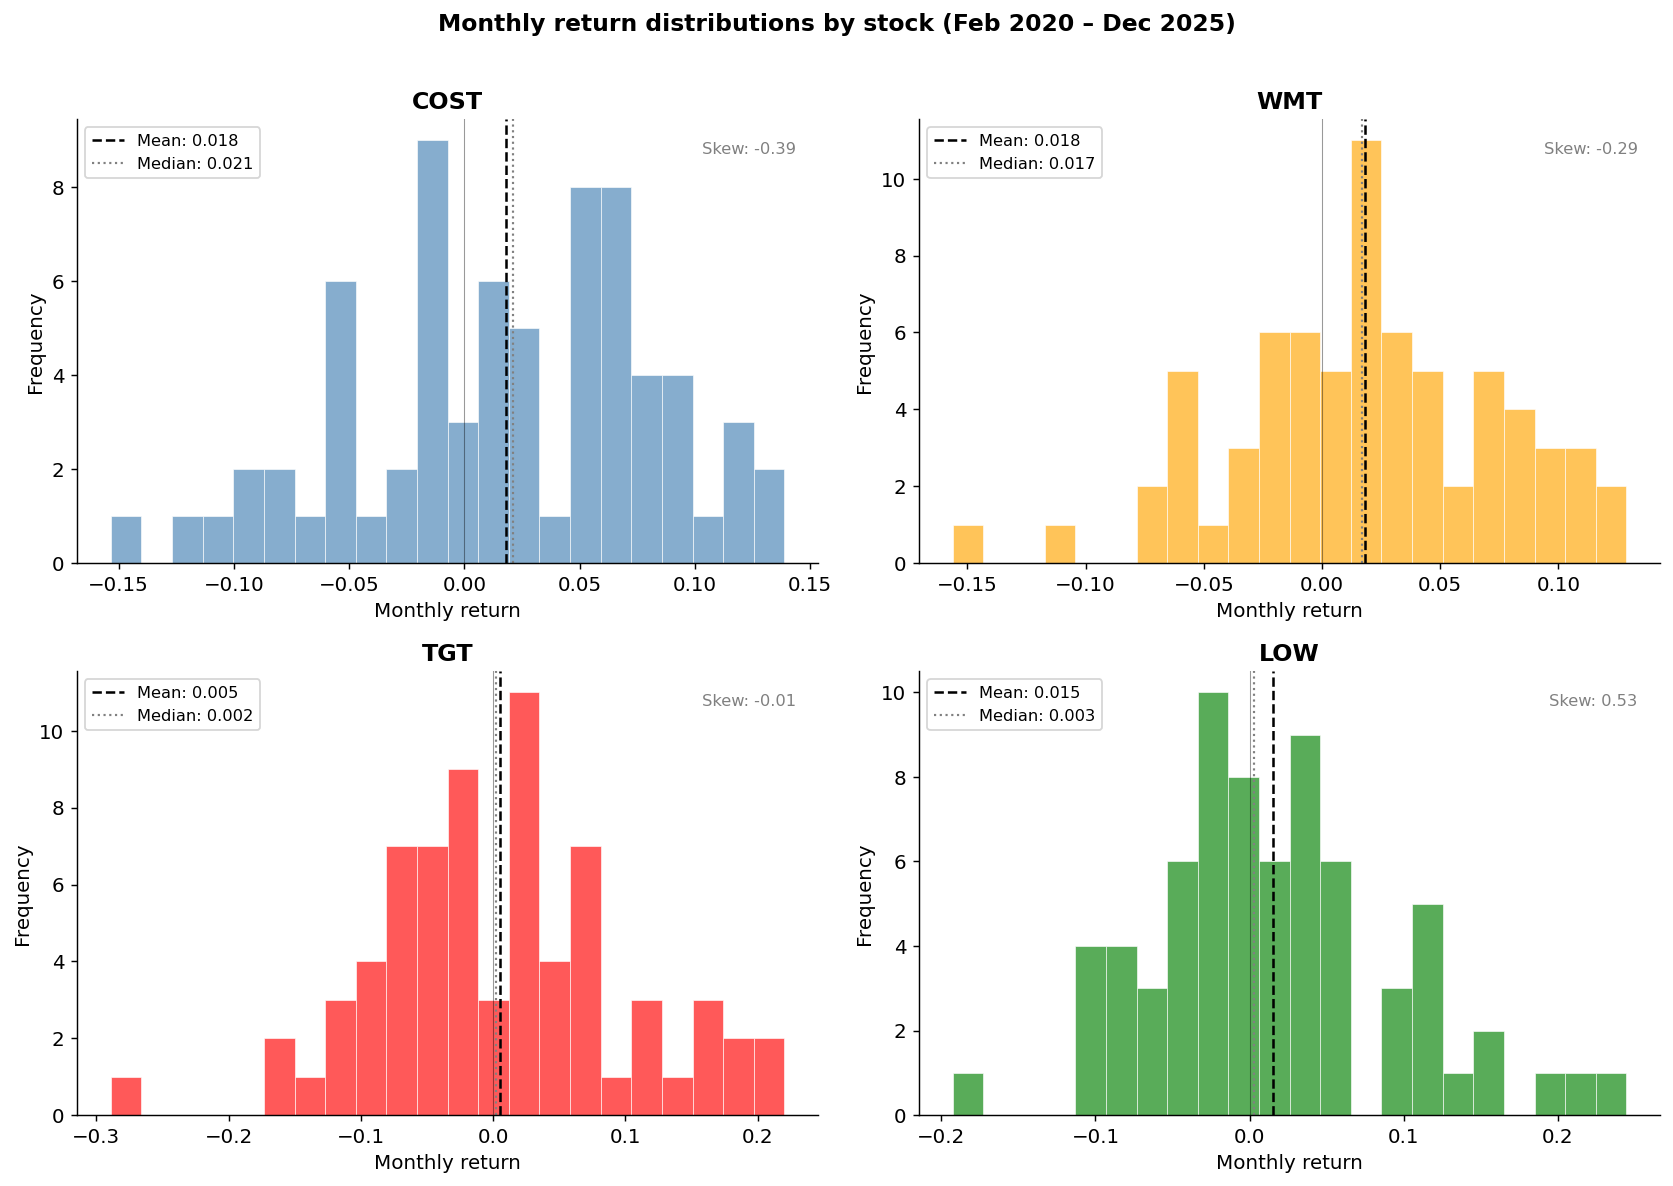


Return summary statistics:
          mean  median     std     min     max    skew
ticker                                                
COST    0.0182  0.0211  0.0652 -0.1535  0.1389 -0.3904
LOW     0.0150  0.0029  0.0807 -0.1925  0.2444  0.5269
TGT     0.0049  0.0020  0.0945 -0.2891  0.2203 -0.0107
WMT     0.0180  0.0171  0.0565 -0.1562  0.1287 -0.2884


In [2]:
# monthly return distributions
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, ticker in zip(axes.flatten(), TICKERS):
    data  = df[df['ticker'] == ticker]['monthly_return']
    color = COLORS[ticker]

    ax.hist(data, bins=22, color=color, alpha=0.65,
            edgecolor='white', linewidth=0.5)

    ax.axvline(data.mean(),   color='black',  linestyle='--',
               linewidth=1.4, label=f'Mean: {data.mean():.3f}')
    ax.axvline(data.median(), color='gray',   linestyle=':',
               linewidth=1.2, label=f'Median: {data.median():.3f}')
    ax.axvline(0,             color='black',  linestyle='-',
               linewidth=0.6, alpha=0.4)

    ax.set_title(f'{ticker}', fontweight='bold')
    ax.set_xlabel('Monthly return')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)

    sk = data.skew()
    ax.text(0.97, 0.95, f'Skew: {sk:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=9, color='gray')

plt.suptitle('Monthly return distributions by stock (Feb 2020 – Dec 2025)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plots/01_return_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# summary table
print("\nReturn summary statistics:")
summary = df.groupby('ticker')['monthly_return'].agg(
    mean='mean', median='median', std='std', min='min', max='max',
    skew=lambda x: x.skew()
).round(4)
print(summary.to_string())

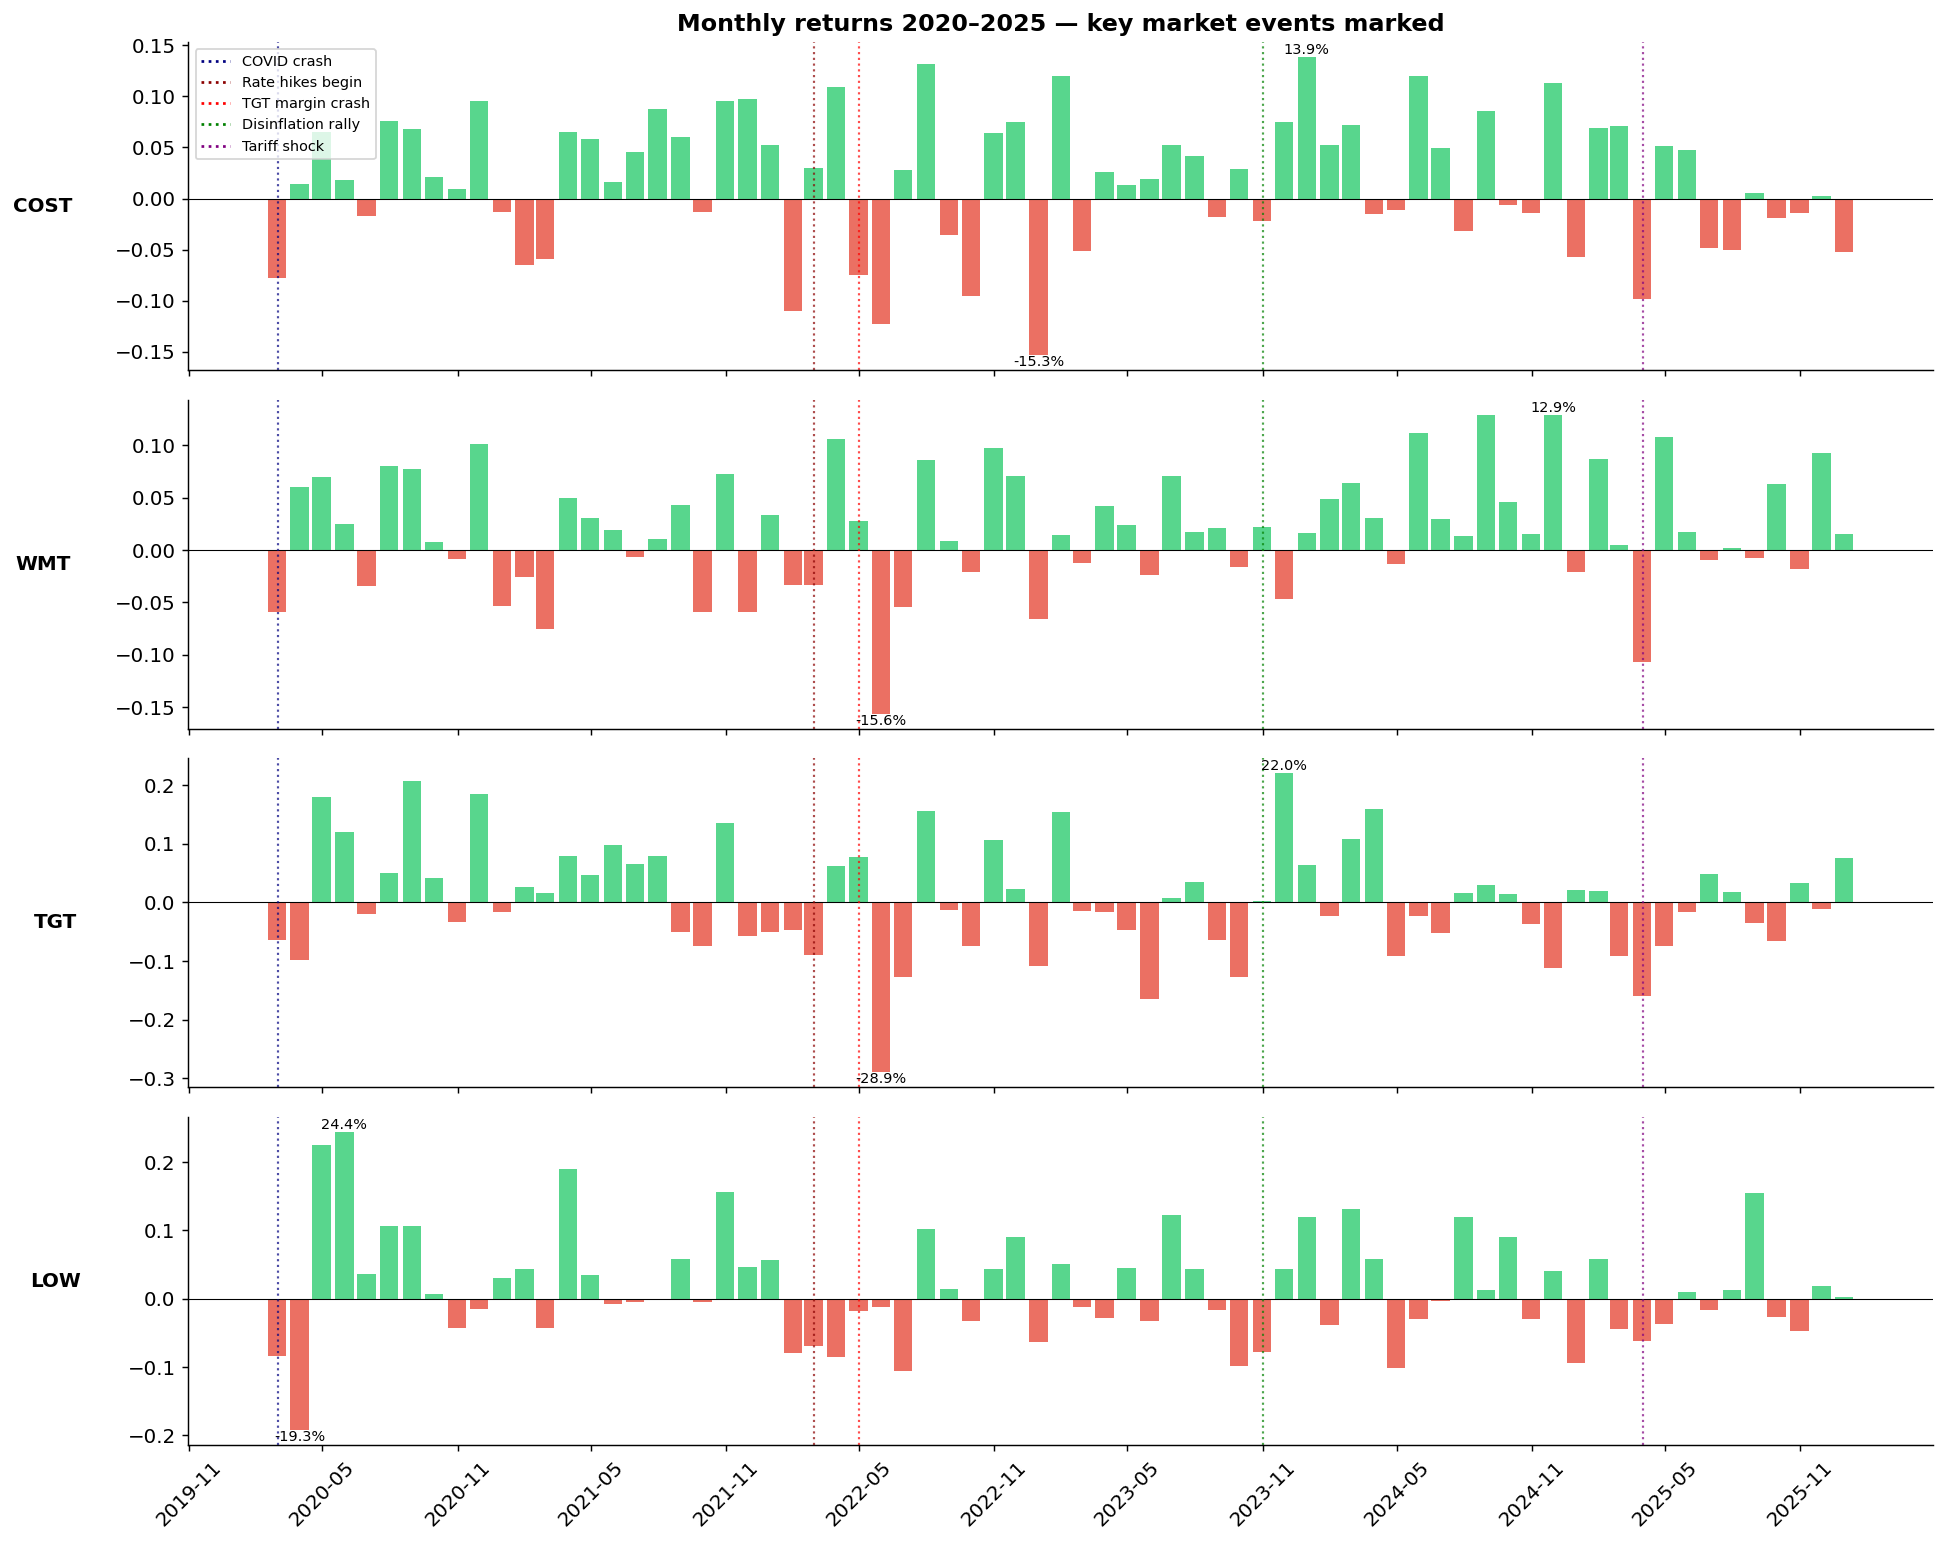

In [3]:
events = {
    '2020-03-01': ('COVID crash',         'navy'),
    '2022-03-01': ('Rate hikes begin',    'darkred'),
    '2022-05-01': ('TGT margin crash',    'red'),
    '2023-11-01': ('Disinflation rally',  'green'),
    '2025-04-01': ('Tariff shock',        'purple'),
}

fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)

for ax, ticker in zip(axes, TICKERS):
    sub = df[df['ticker'] == ticker].sort_values('date')
    colors_bar = ['#2ecc71' if r > 0 else '#e74c3c'
                  for r in sub['monthly_return']]

    ax.bar(sub['date'], sub['monthly_return'],
           color=colors_bar, alpha=0.8, width=25)
    ax.axhline(0, color='black', linewidth=0.6)
    ax.set_ylabel(ticker, fontweight='bold', rotation=0,
                  labelpad=40, va='center')

    for date_str, (label, ec) in events.items():
        ax.axvline(pd.Timestamp(date_str), color=ec,
                   linestyle=':', linewidth=1.2, alpha=0.7)

    # annotate the most extreme month per stock
    idx_max = sub['monthly_return'].idxmax()
    idx_min = sub['monthly_return'].idxmin()
    for idx, va in [(idx_max, 'bottom'), (idx_min, 'top')]:
        row = sub.loc[idx]
        ax.annotate(f"{row['monthly_return']:.1%}",
                    xy=(row['date'], row['monthly_return']),
                    fontsize=8, color='black', va=va, ha='center')

legend_handles = [
    plt.Line2D([0], [0], color=ec, linestyle=':', linewidth=1.5, label=label)
    for _, (label, ec) in events.items()
]
axes[0].legend(handles=legend_handles, fontsize=8,
               loc='upper left', framealpha=0.8)

axes[0].set_title('Monthly returns 2020–2025 — key market events marked',
                   fontweight='bold')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plots/02_returns_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

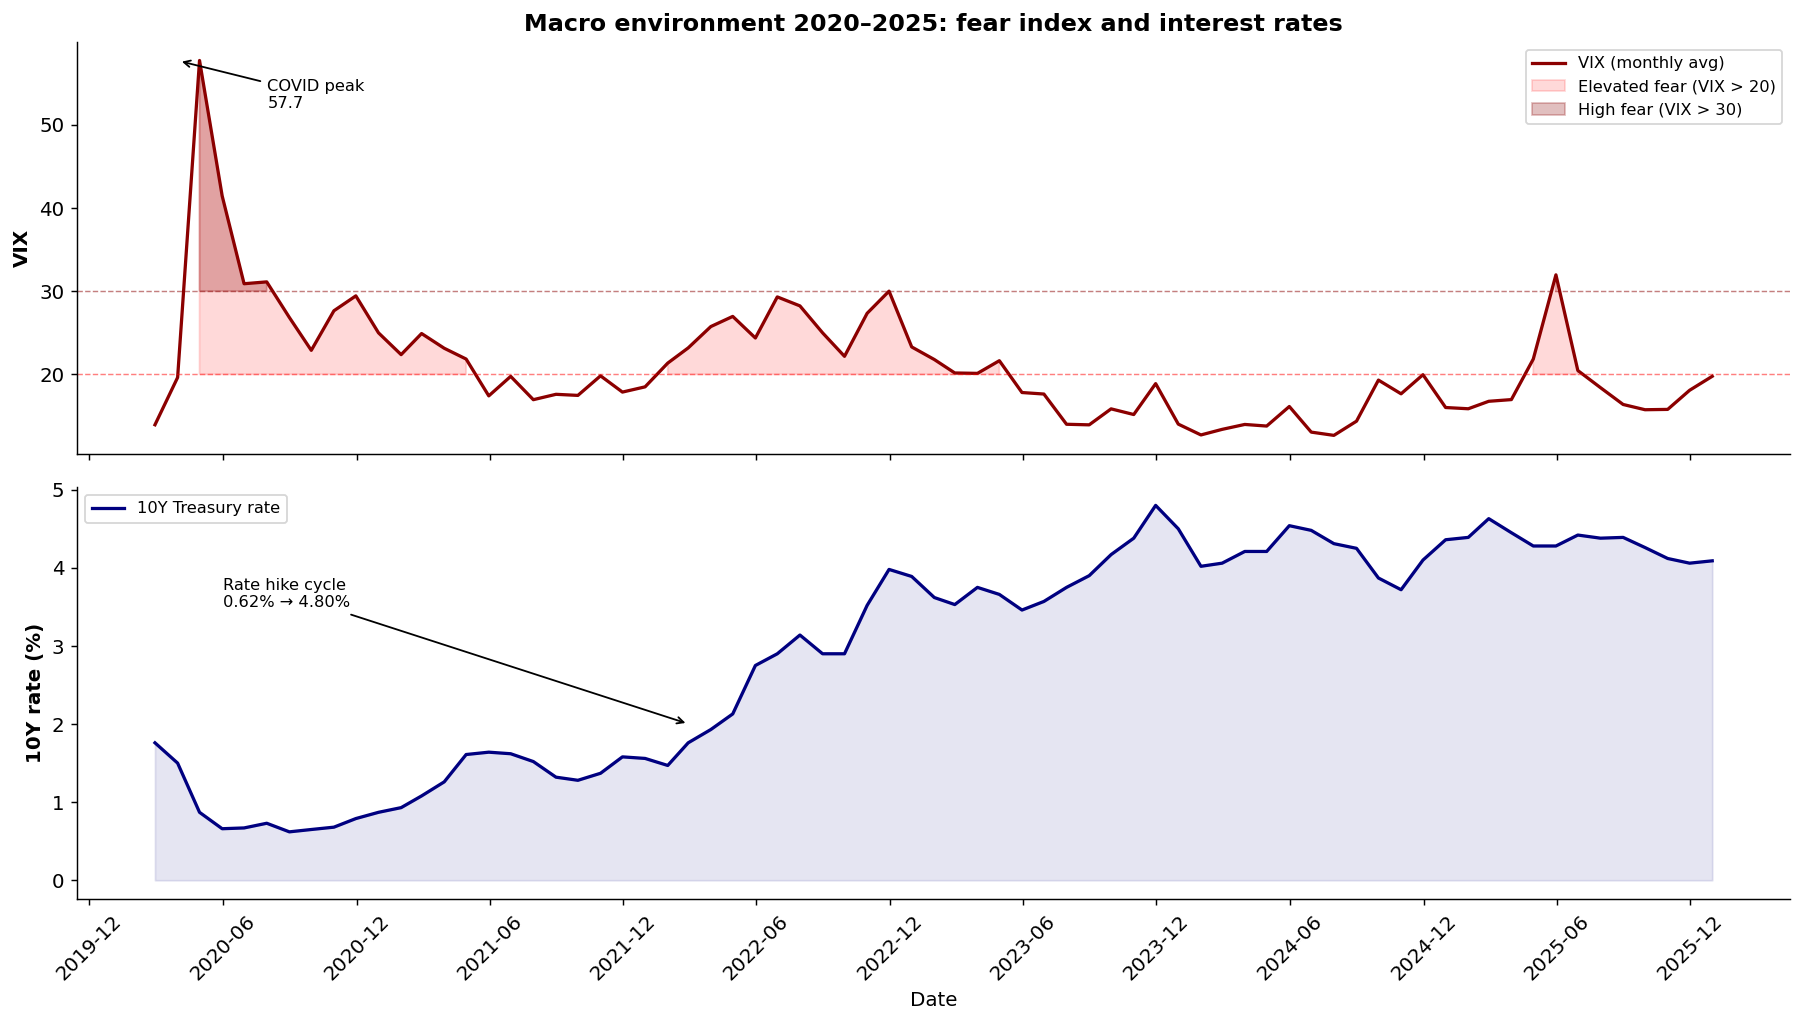

VIX statistics:
count    71.00
mean     21.03
std       7.17
min      12.67
25%      16.26
50%      19.76
75%      23.84
max      57.74
Name: vix_avg, dtype: float64

10Y rate statistics:
count    71.00
mean      2.94
std       1.41
min       0.62
25%       1.54
50%       3.57
75%       4.21
max       4.80
Name: rate_10y, dtype: float64

Months with VIX > 30: 24 rows
Up month rate when VIX > 30  : 83.3%
Up month rate when VIX ≤ 30  : 54.6%
Up month rate when rate > 3%  : 58.8%
Up month rate when rate ≤ 3%  : 54.8%


In [4]:
macro = df[['date', 'vix_avg', 'rate_10y']].drop_duplicates().sort_values('date')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# looking at vix (volatility)
ax1.plot(macro['date'], macro['vix_avg'],
         color='darkred', linewidth=1.8, label='VIX (monthly avg)')
ax1.fill_between(macro['date'], macro['vix_avg'], 20,
                 where=macro['vix_avg'] > 20,
                 alpha=0.15, color='red', label='Elevated fear (VIX > 20)')
ax1.fill_between(macro['date'], macro['vix_avg'], 30,
                 where=macro['vix_avg'] > 30,
                 alpha=0.25, color='darkred', label='High fear (VIX > 30)')
ax1.axhline(20, color='red',     linestyle='--', linewidth=0.8, alpha=0.5)
ax1.axhline(30, color='darkred', linestyle='--', linewidth=0.8, alpha=0.5)
ax1.set_ylabel('VIX', fontweight='bold')
ax1.legend(fontsize=9, loc='upper right')
ax1.annotate('COVID peak\n57.7', xy=(pd.Timestamp('2020-04-01'), 57.7),
             xytext=(pd.Timestamp('2020-08-01'), 52),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=9)

# 10 year rate
ax2.plot(macro['date'], macro['rate_10y'],
         color='navy', linewidth=1.8, label='10Y Treasury rate')
ax2.fill_between(macro['date'], macro['rate_10y'], 0,
                 alpha=0.10, color='navy')
ax2.set_ylabel('10Y rate (%)', fontweight='bold')
ax2.set_xlabel('Date')
ax2.legend(fontsize=9, loc='upper left')
ax2.annotate('Rate hike cycle\n0.62% → 4.80%',
             xy=(pd.Timestamp('2022-03-01'), 2.0),
             xytext=(pd.Timestamp('2020-06-01'), 3.5),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=9)

ax1.set_title('Macro environment 2020–2025: fear index and interest rates',
              fontweight='bold')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plots/03_macro_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

# key macro statistics
print("VIX statistics:")
print(macro['vix_avg'].describe().round(2))
print("\n10Y rate statistics:")
print(macro['rate_10y'].describe().round(2))
print(f"\nMonths with VIX > 30: {(df['vix_avg'] > 30).sum()} rows")
print(f"Up month rate when VIX > 30  : {df[df['vix_avg'] > 30]['target'].mean():.1%}")
print(f"Up month rate when VIX ≤ 30  : {df[df['vix_avg'] <= 30]['target'].mean():.1%}")
print(f"Up month rate when rate > 3%  : {df[df['rate_10y'] > 3]['target'].mean():.1%}")
print(f"Up month rate when rate ≤ 3%  : {df[df['rate_10y'] <= 3]['target'].mean():.1%}")

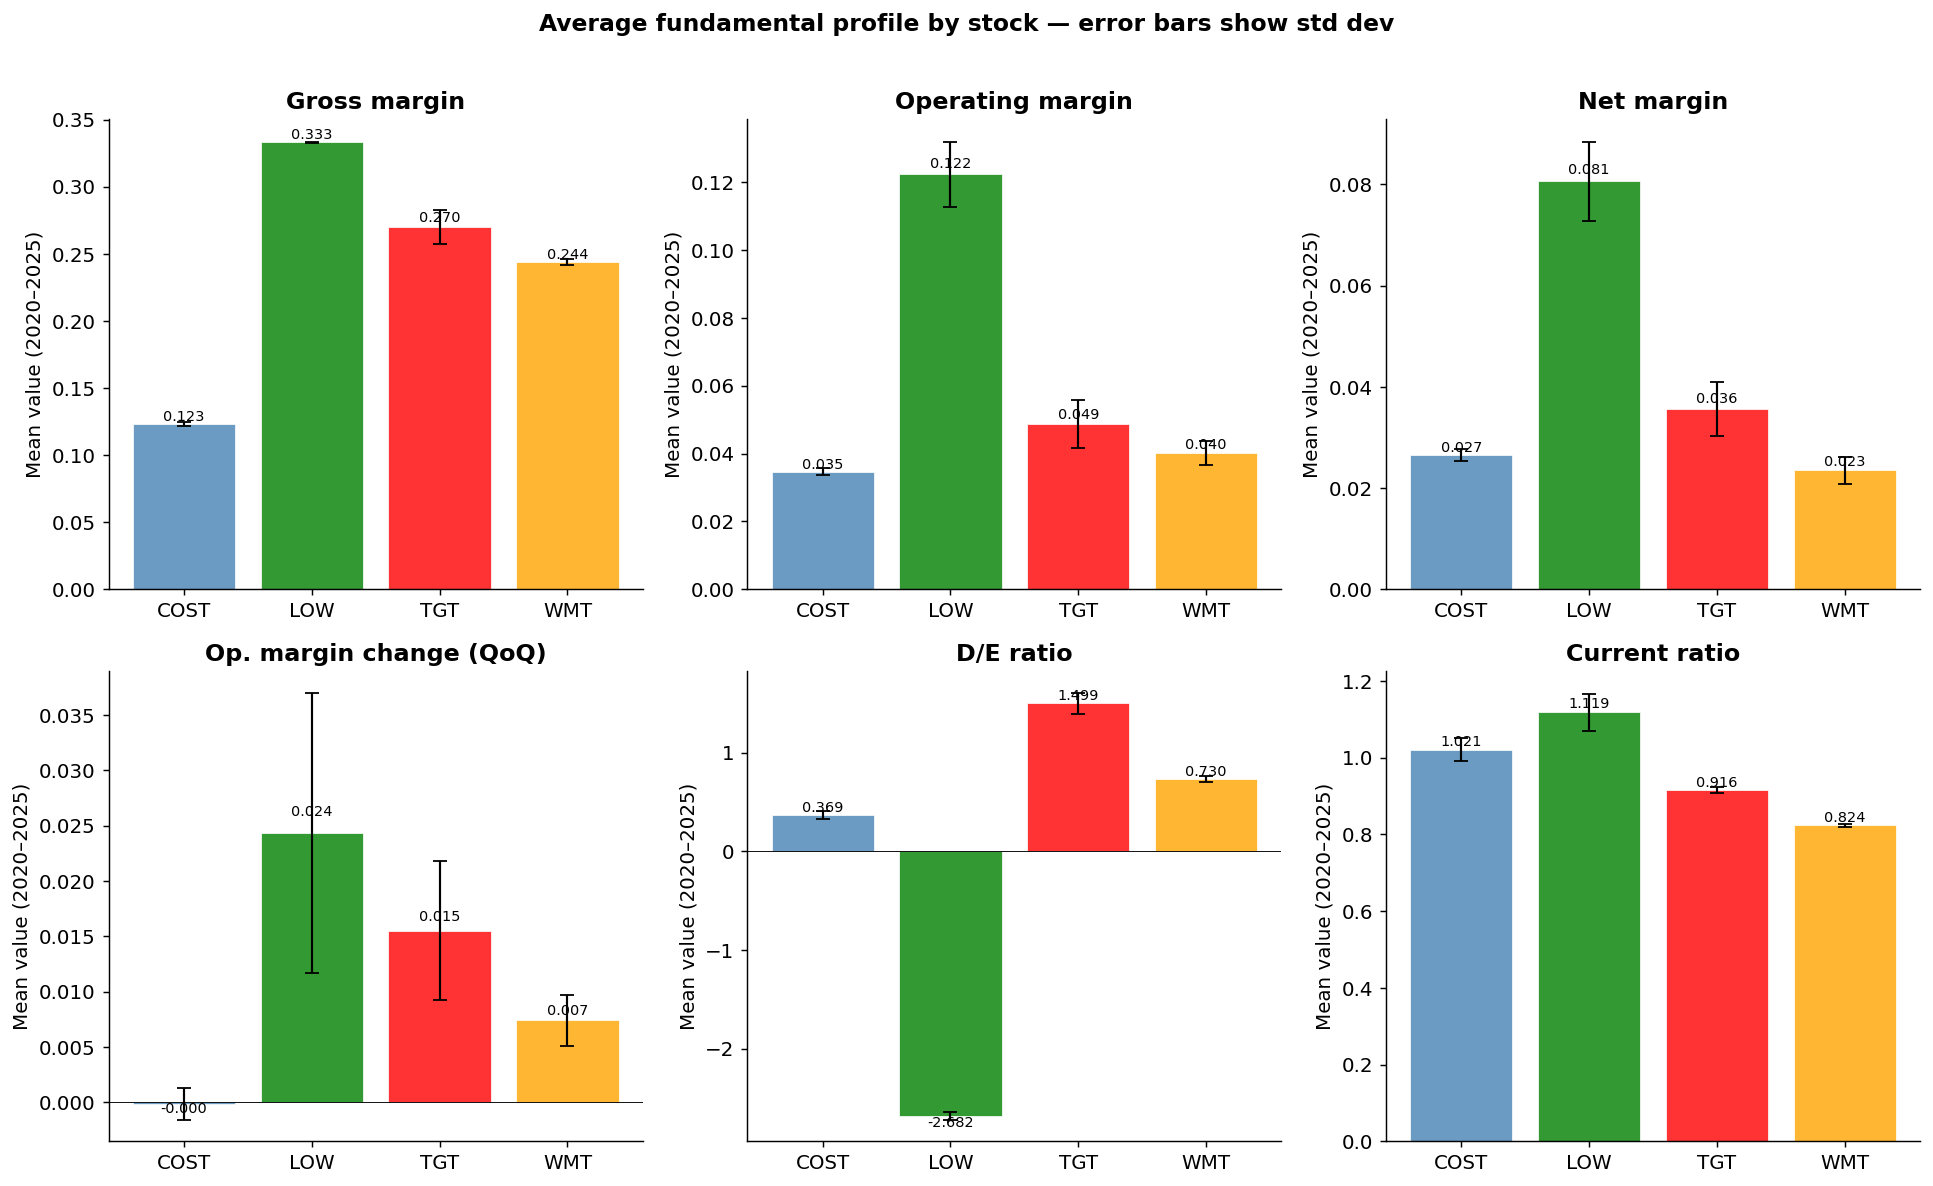


Cross-stock fundamental means:
        gross_margin  operating_margin  net_margin  op_margin_change  de_ratio  current_ratio
ticker                                                                                       
COST          0.1231            0.0347      0.0265           -0.0001    0.3686         1.0205
LOW           0.3331            0.1222      0.0807            0.0243   -2.6823         1.1185
TGT           0.2700            0.0488      0.0357            0.0155    1.4988         0.9163
WMT           0.2439            0.0401      0.0235            0.0074    0.7301         0.8238

Note: LOW de_ratio is negative due to negative stockholders equity
(result of aggressive share buybacks — not financial distress)


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

plot_cols = ['gross_margin', 'operating_margin', 'net_margin',
             'op_margin_change', 'de_ratio', 'current_ratio']
titles = ['Gross margin', 'Operating margin', 'Net margin',
          'Op. margin change (QoQ)', 'D/E ratio', 'Current ratio']

for ax, col, title in zip(axes.flatten(), plot_cols, titles):
    means  = df.groupby('ticker')[col].mean()
    stds   = df.groupby('ticker')[col].std()
    colors = [COLORS[t] for t in means.index]

    bars = ax.bar(means.index, means.values, color=colors,
                  alpha=0.8, edgecolor='white', linewidth=0.5)
    ax.errorbar(means.index, means.values, yerr=stds.values,
                fmt='none', color='black', capsize=4, linewidth=1.2)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Mean value (2020–2025)')

    for bar, val in zip(bars, means.values):
        va  = 'bottom' if val >= 0 else 'top'
        ypos = val + (stds[means.index[list(means.values).index(val)]] * 0.1)
        ax.text(bar.get_x() + bar.get_width()/2, ypos,
                f'{val:.3f}', ha='center', va=va, fontsize=8)

plt.suptitle('Average fundamental profile by stock — error bars show std dev',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plots/04_fundamental_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCross-stock fundamental means:")
print(df.groupby('ticker')[plot_cols].mean().round(4).to_string())
print("\nNote: LOW de_ratio is negative due to negative stockholders equity")
print("(result of aggressive share buybacks — not financial distress)")

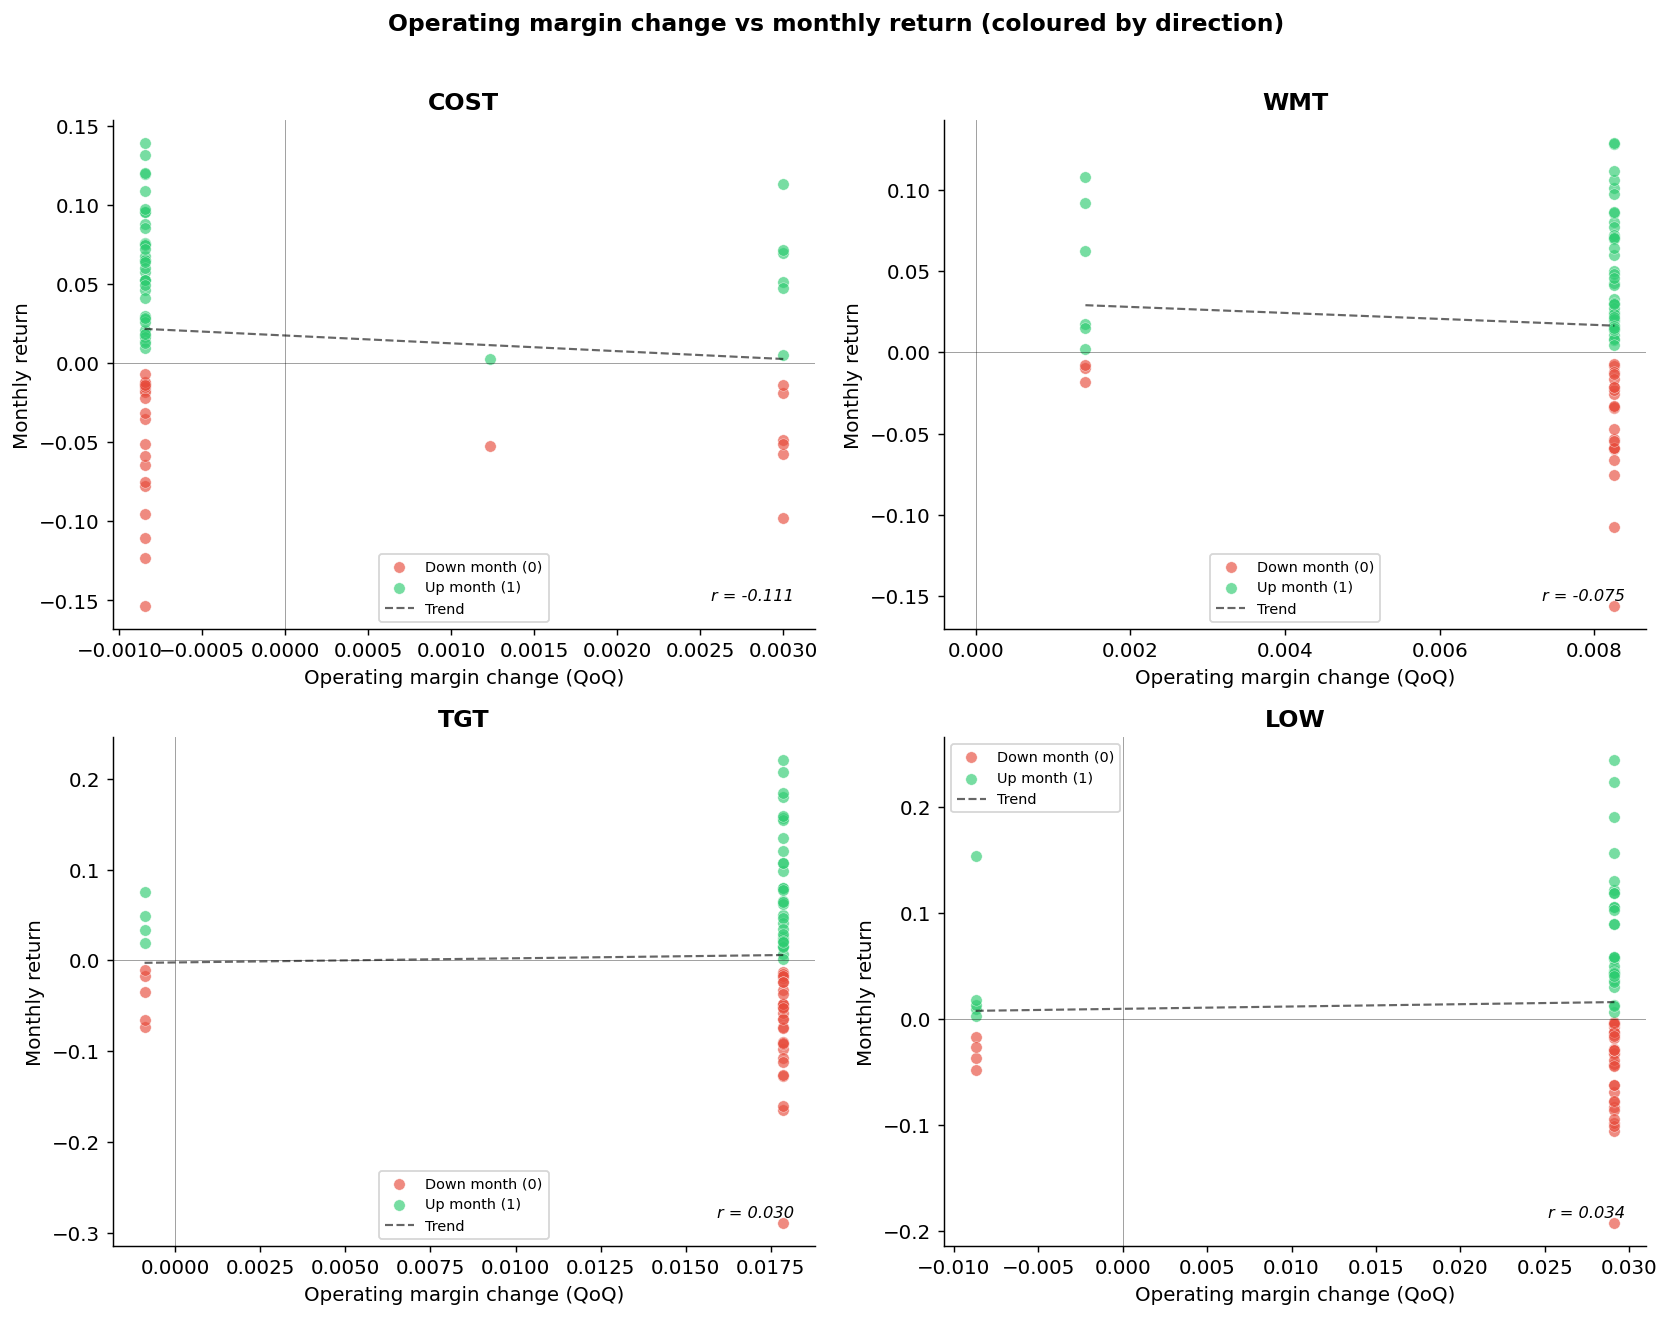


Correlation: op_margin_change vs monthly_return per ticker:
  COST: r = -0.1113
  WMT: r = -0.0748
  TGT: r = 0.0304
  LOW: r = 0.0342
  Pooled: r = -0.0159


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for ax, ticker in zip(axes.flatten(), TICKERS):
    sub  = df[df['ticker'] == ticker].copy()
    up   = sub[sub['target'] == 1]
    down = sub[sub['target'] == 0]

    ax.scatter(down['op_margin_change'], down['monthly_return'],
               color='#e74c3c', alpha=0.65, s=40, label='Down month (0)',
               edgecolors='white', linewidths=0.3)
    ax.scatter(up['op_margin_change'],   up['monthly_return'],
               color='#2ecc71', alpha=0.65, s=40, label='Up month (1)',
               edgecolors='white', linewidths=0.3)

    # Trend line
    z = np.polyfit(sub['op_margin_change'], sub['monthly_return'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(sub['op_margin_change'].min(),
                          sub['op_margin_change'].max(), 100)
    ax.plot(x_line, p(x_line), color='black', linewidth=1.2,
            linestyle='--', alpha=0.6, label='Trend')

    ax.axhline(0, color='black', linewidth=0.5, alpha=0.4)
    ax.axvline(0, color='black', linewidth=0.5, alpha=0.4)
    ax.set_xlabel('Operating margin change (QoQ)')
    ax.set_ylabel('Monthly return')
    ax.set_title(ticker, fontweight='bold')
    ax.legend(fontsize=8)

    # Correlation annotation
    r = sub['op_margin_change'].corr(sub['monthly_return'])
    ax.text(0.97, 0.05, f'r = {r:.3f}', transform=ax.transAxes,
            ha='right', va='bottom', fontsize=9,
            color='black', style='italic')

plt.suptitle('Operating margin change vs monthly return (coloured by direction)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plots/05_opmargin_vs_return.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCorrelation: op_margin_change vs monthly_return per ticker:")
for ticker in TICKERS:
    sub = df[df['ticker'] == ticker]
    r   = sub['op_margin_change'].corr(sub['monthly_return'])
    print(f"  {ticker}: r = {r:.4f}")
print(f"  Pooled: r = {df['op_margin_change'].corr(df['monthly_return']):.4f}")

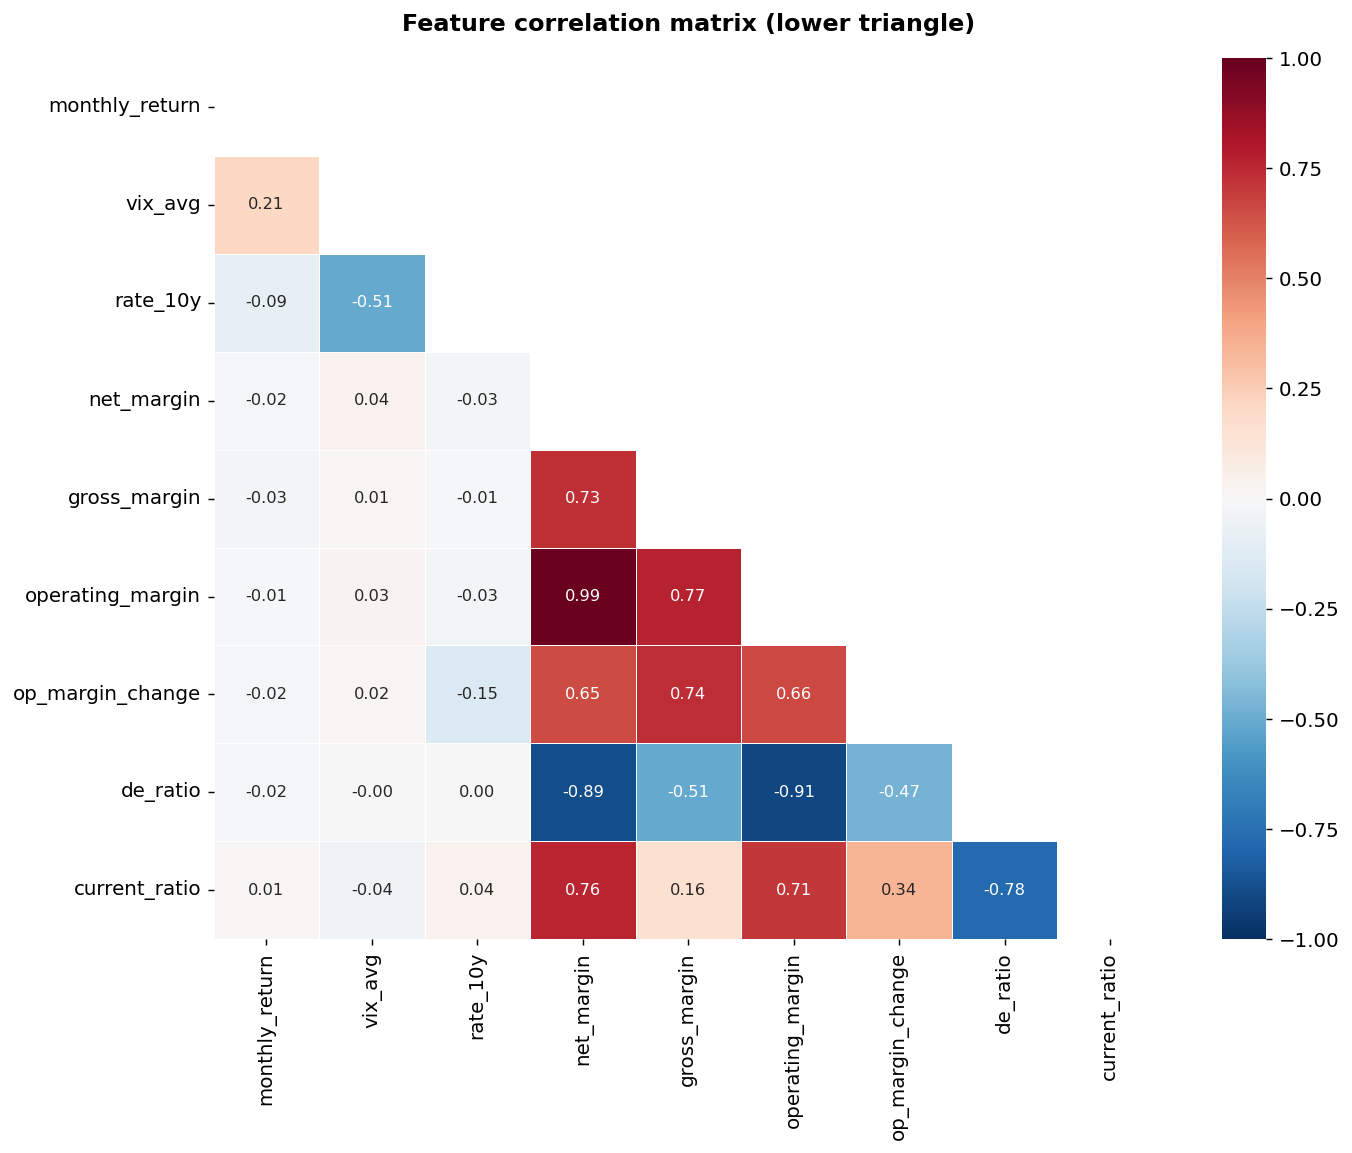


Feature pairs with |correlation| > 0.5 (potential multicollinearity):
  vix_avg vs rate_10y: r = -0.51
  net_margin vs gross_margin: r = 0.73
  net_margin vs operating_margin: r = 0.99
  net_margin vs op_margin_change: r = 0.65
  net_margin vs de_ratio: r = -0.89
  net_margin vs current_ratio: r = 0.76
  gross_margin vs operating_margin: r = 0.77
  gross_margin vs op_margin_change: r = 0.74
  gross_margin vs de_ratio: r = -0.51
  operating_margin vs op_margin_change: r = 0.66
  operating_margin vs de_ratio: r = -0.91
  operating_margin vs current_ratio: r = 0.71
  de_ratio vs current_ratio: r = -0.78

Correlations with monthly_return:
vix_avg             0.21
rate_10y           -0.09
gross_margin       -0.03
net_margin         -0.02
op_margin_change   -0.02
de_ratio           -0.02
operating_margin   -0.01
current_ratio       0.01


In [7]:
feature_cols = ['monthly_return', 'vix_avg', 'rate_10y',
                'net_margin', 'gross_margin', 'operating_margin',
                'op_margin_change', 'de_ratio', 'current_ratio']

corr = df[feature_cols].corr().round(2)

# mask upper triangle
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    ax=ax, linewidths=0.5, linecolor='white',
    annot_kws={'size': 9}
)
ax.set_title('Feature correlation matrix (lower triangle)',
             fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plots/06_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# flag multicollinearity 
print("\nFeature pairs with |correlation| > 0.5 (potential multicollinearity):")
for i in range(len(feature_cols)):
    for j in range(i+1, len(feature_cols)):
        val = corr.iloc[i, j]
        if abs(val) > 0.5:
            print(f"  {feature_cols[i]} vs {feature_cols[j]}: r = {val:.2f}")

print("\nCorrelations with monthly_return:")
print(corr['monthly_return'].drop('monthly_return').sort_values(
    key=abs, ascending=False).to_string())

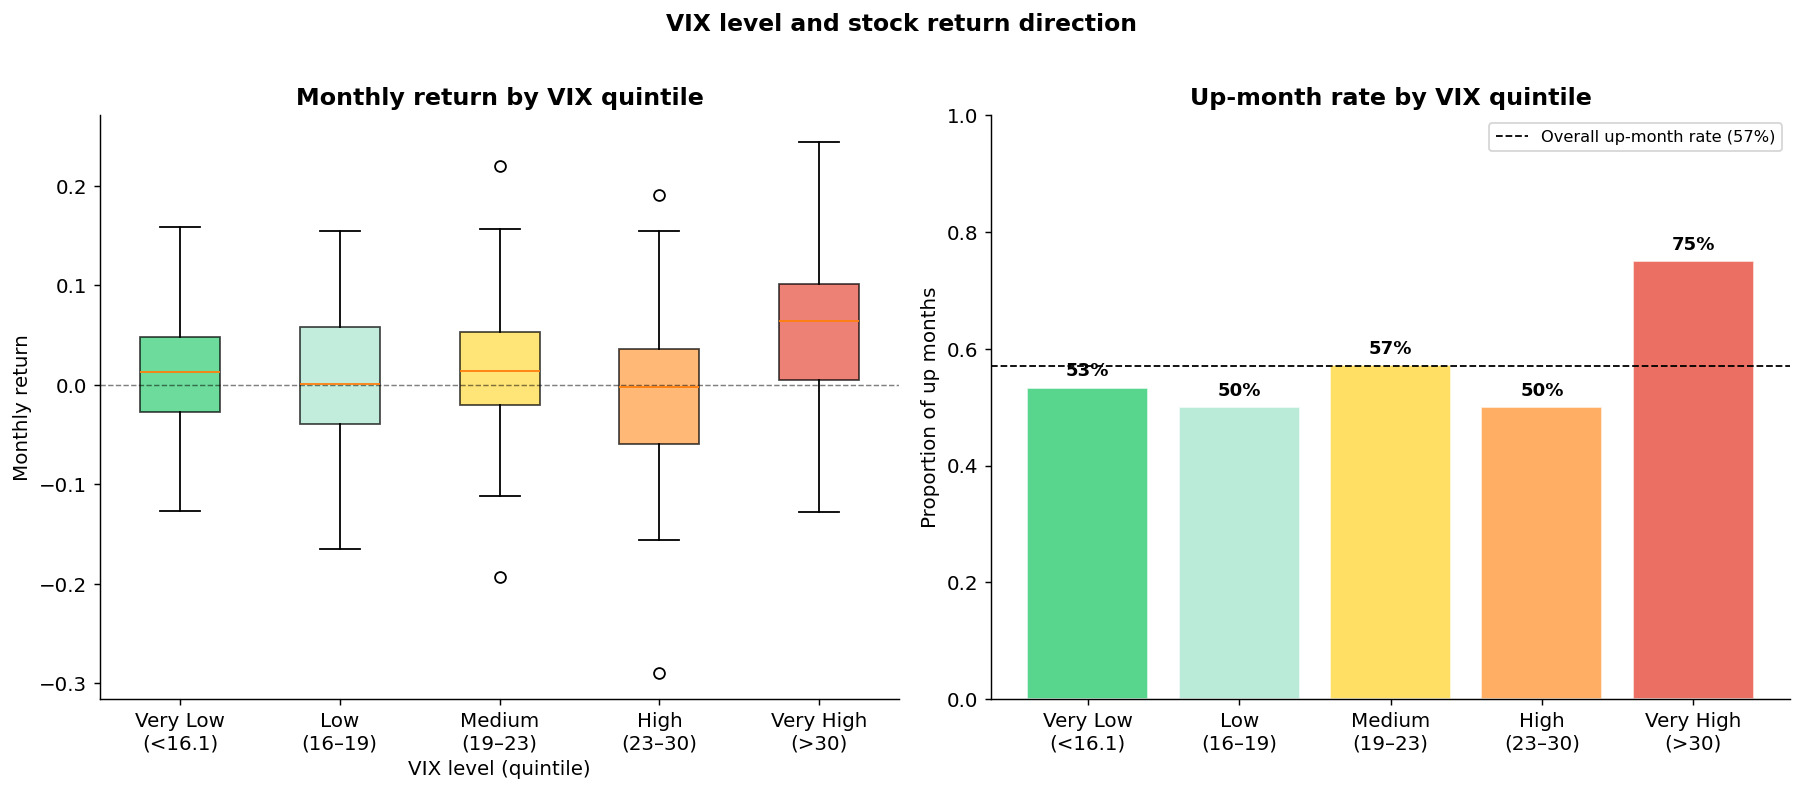


Up-month rate and mean return by VIX quintile:
                   up_rate  mean_return  count
vix_quintile                                  
Very Low\n(<16.1)    0.533        0.009     60
Low\n(16–19)         0.500        0.003     56
Medium\n(19–23)      0.571        0.014     56
High\n(23–30)        0.500       -0.010     56
Very High\n(>30)     0.750        0.054     56


In [8]:
df['vix_quintile'] = pd.qcut(
    df['vix_avg'], q=5,
    labels=['Very Low\n(<16.1)', 'Low\n(16–19)', 'Medium\n(19–23)',
            'High\n(23–30)', 'Very High\n(>30)']
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Box plot of returns by vix quintile
data_by_q = [df[df['vix_quintile'] == q]['monthly_return'].values
             for q in df['vix_quintile'].cat.categories]
bp = ax1.boxplot(data_by_q, patch_artist=True, notch=False,
                 labels=df['vix_quintile'].cat.categories)

colors_q = ['#2ecc71', '#a8e6cf', '#ffd93d', '#ff9a3c', '#e74c3c']
for patch, color in zip(bp['boxes'], colors_q):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax1.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax1.set_title('Monthly return by VIX quintile', fontweight='bold')
ax1.set_xlabel('VIX level (quintile)')
ax1.set_ylabel('Monthly return')

# Up-month rate by quintile
up_rate = df.groupby('vix_quintile', observed=True)['target'].mean()
bars = ax2.bar(range(len(up_rate)), up_rate.values,
               color=colors_q, alpha=0.8, edgecolor='white')
ax2.axhline(0.57, color='black', linestyle='--', linewidth=1,
            label='Overall up-month rate (57%)')
ax2.set_xticks(range(len(up_rate)))
ax2.set_xticklabels(df['vix_quintile'].cat.categories)
ax2.set_title('Up-month rate by VIX quintile', fontweight='bold')
ax2.set_ylabel('Proportion of up months')
ax2.set_ylim(0, 1)
ax2.legend(fontsize=9)

for bar, val in zip(bars, up_rate.values):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.02,
             f'{val:.0%}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('VIX level and stock return direction',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plots/07_return_by_vix_quintile.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nUp-month rate and mean return by VIX quintile:")
summary_q = df.groupby('vix_quintile', observed=True).agg(
    up_rate=('target', 'mean'),
    mean_return=('monthly_return', 'mean'),
    count=('monthly_return', 'count')
).round(3)
print(summary_q.to_string())

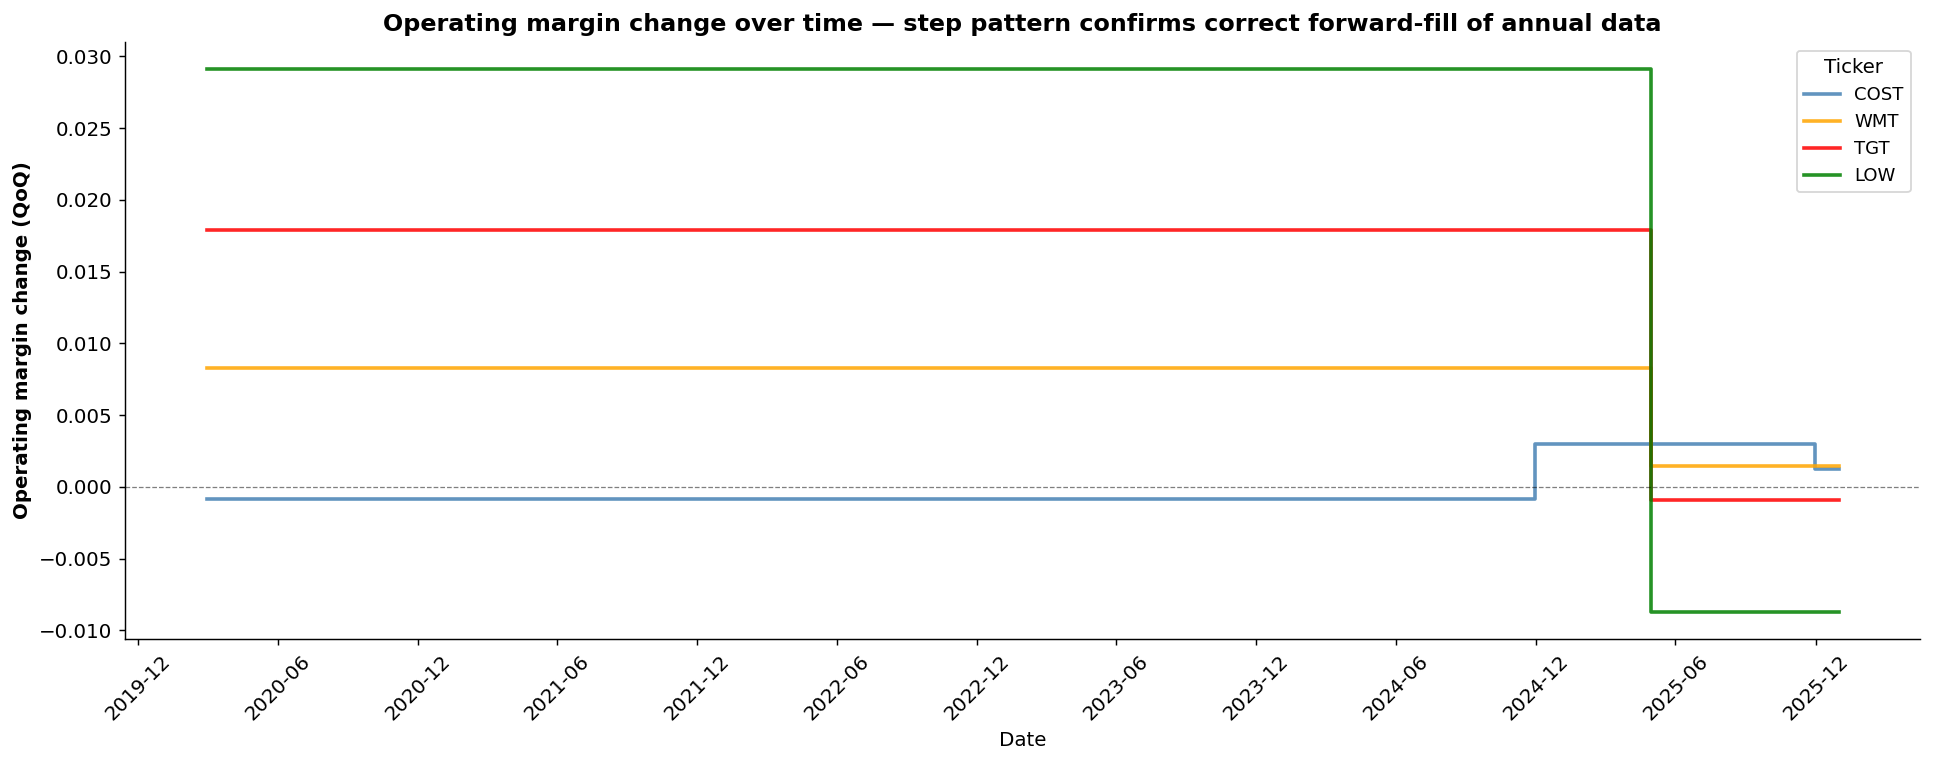

Distinct op_margin_change values per ticker:
  COST: [np.float64(-0.0008), np.float64(0.0012), np.float64(0.003)]
  WMT: [np.float64(0.0014), np.float64(0.0083)]
  TGT: [np.float64(-0.0009), np.float64(0.0179)]
  LOW: [np.float64(-0.0087), np.float64(0.0291)]


In [9]:
fig, ax = plt.subplots(figsize=(15, 6))

for ticker in TICKERS:
    sub = df[df['ticker'] == ticker].sort_values('date')
    ax.step(sub['date'], sub['op_margin_change'],
            label=ticker, color=COLORS[ticker],
            linewidth=2, where='post', alpha=0.85)

ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.5)
ax.set_ylabel('Operating margin change (QoQ)', fontweight='bold')
ax.set_xlabel('Date')
ax.set_title('Operating margin change over time — step pattern confirms '
             'correct forward-fill of annual data', fontweight='bold')
ax.legend(title='Ticker', fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plots/08_opmargin_change_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

print("Distinct op_margin_change values per ticker:")
for ticker in TICKERS:
    vals = df[df['ticker'] == ticker]['op_margin_change'].unique()
    print(f"  {ticker}: {sorted(vals.round(4))}")

In [10]:
print("=" * 60)
print("  EDA SUMMARY — Key findings")
print("=" * 60)

print("\n[1] Return statistics by stock:")
print(df.groupby('ticker')['monthly_return'].agg(
    mean='mean', std='std', min='min', max='max'
).round(4).to_string())

print("\n[2] Up-month rate by stock:")
print(df.groupby('ticker')['target'].mean().round(3).to_string())

print("\n[3] Up-month rate in different macro environments:")
print(f"  VIX > 30      : {df[df['vix_avg'] > 30]['target'].mean():.1%}")
print(f"  VIX 20–30     : {df[(df['vix_avg'] > 20) & (df['vix_avg'] <= 30)]['target'].mean():.1%}")
print(f"  VIX < 20      : {df[df['vix_avg'] < 20]['target'].mean():.1%}")
print(f"  Rate > 4%     : {df[df['rate_10y'] > 4]['target'].mean():.1%}")
print(f"  Rate < 2%     : {df[df['rate_10y'] < 2]['target'].mean():.1%}")

print("\n[4] Strongest feature correlations with monthly_return (pooled):")
feature_cols = ['vix_avg', 'rate_10y', 'net_margin', 'gross_margin',
                'operating_margin', 'op_margin_change', 'de_ratio', 'current_ratio']
corrs = {col: df['monthly_return'].corr(df[col]) for col in feature_cols}
corrs_sorted = sorted(corrs.items(), key=lambda x: abs(x[1]), reverse=True)
for feat, r in corrs_sorted:
    print(f"  {feat:<22}: r = {r:+.4f}")

print("\n[5] Features with >0.7 cross-correlation (multicollinearity risk):")
corr_matrix = df[feature_cols].corr()
found = False
for i in range(len(feature_cols)):
    for j in range(i+1, len(feature_cols)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.7:
            print(f"  {feature_cols[i]} vs {feature_cols[j]}: r = {val:.3f}")
            found = True
if not found:
    print("  None above 0.7")

print("\n[6] Features to carry into hypothesis testing:")
print("  Strong candidates : vix_avg, op_margin_change")
print("  Moderate candidates: rate_10y, operating_margin, net_margin")
print("  Weak / drop from tests: current_ratio")
print("  Special note: de_ratio excluded from pooled tests (LOW negative equity)")
print("=" * 60)

  EDA SUMMARY — Key findings

[1] Return statistics by stock:
          mean     std     min     max
ticker                                
COST    0.0182  0.0652 -0.1535  0.1389
LOW     0.0150  0.0807 -0.1925  0.2444
TGT     0.0049  0.0945 -0.2891  0.2203
WMT     0.0180  0.0565 -0.1562  0.1287

[2] Up-month rate by stock:
ticker
COST    0.620
LOW     0.507
TGT     0.507
WMT     0.648

[3] Up-month rate in different macro environments:
  VIX > 30      : 83.3%
  VIX 20–30     : 51.0%
  VIX < 20      : 57.1%
  Rate > 4%     : 56.7%
  Rate < 2%     : 60.6%

[4] Strongest feature correlations with monthly_return (pooled):
  vix_avg               : r = +0.2141
  rate_10y              : r = -0.0899
  gross_margin          : r = -0.0327
  de_ratio              : r = -0.0236
  net_margin            : r = -0.0176
  op_margin_change      : r = -0.0159
  operating_margin      : r = -0.0128
  current_ratio         : r = +0.0072

[5] Features with >0.7 cross-correlation (multicollinearity risk):
  